# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Creating class MLP only using numpy

In [2]:
class MLP_NP:
    def __init__(self, MLP_architecture, learning_rate, momentum, activation_function='sigmoid'):
       
        """
        MLP_architecture: [input_size (dataset features), hidden_layer1_size, hidden_layer2_size, ..., output_size (possible classes)]
        learning_rate: learning rate for weight updates
        momentum: momentum factor for weight updates
        activation_function: choice of activation function for hidden layers (default is 'sigmoid', can also be 'relu') and 'softmax' for output layer
        """
        self.MLP_architecture = MLP_architecture
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.activation_function = activation_function

        """
        weights: list of weight matrices for each layer (including input to first hidden layer and last hidden layer to output layer)
        biases: list of bias vectors for each layer (including first hidden layer and output layer)
        weight_speed: list of matrices to store the previous weight updates for momentum calculation
        bias_speed: list of vectors to store the previous bias updates for momentum calculation
        """
        self.weights = []
        self.biases = []
        self.weight_speed = []
        self.biases_speed = []
       
        # initialization of the weights and biases
        for i in range(len(MLP_architecture) - 1):
       
            # input and output size for the current layer
            input_size = MLP_architecture[i]
            output_size = MLP_architecture[i + 1]
            
            # initialize weights with small random values and biases with zeros
            weight_matrix = np.random.randn(input_size, output_size) * 0.1
            bias_vector = np.zeros((1, output_size))
           
            # store the initialized weights and biases in the respective lists
            self.weights.append(weight_matrix)
            self.biases.append(bias_vector)

            # Initialize speed matrices for momentum
            self.weight_speed.append(np.zeros_like(weight_matrix))
            self.biases_speed.append(np.zeros_like(bias_vector))
    
    """
    Activation functions: Sigmoid, ReLU, softmax, and their derivatives
    their porpouse is to introduce non-linearity into the model, allowing it to learn complex patterns in the data. The derivatives are used during backpropagation to compute gradients for weight updates.
    """
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    """
    Forward pass: computes the output of the network for a given input by passing the data through each layer and applying the activation functions.
    """
    def forward_pass(self, X):

        """
        X: input data (shape: [num_samples, input_size])
        layer_inputs: list to store the inputs to each layer (including the original input X) for use in backpropagation
        layer_outputs: list to store the outputs of each layer for use in backpropagation
        """
        self.layer_inputs = []  
        self.layer_outputs = [] 
        
        input_data = X
        for i in range(len(self.MLP_architecture) - 1):

            # Compute the linear transformation (z) for the current layer and store it for backpropagation
            z = np.dot(input_data, self.weights[i]) + self.biases[i]
            self.layer_inputs.append(z)

            # Apply the appropriate activation function based on the layer type and the function specified in the constructor
            if i < len(self.MLP_architecture) - 2:  # Hidden layers
                if self.activation_function == 'sigmoid':
                    output_data = self.sigmoid(z)
                elif self.activation_function == 'relu':
                    output_data = self.relu(z)
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")

            # aplying softmax activation function to the output layer regardless of the specified activation function for hidden layers, as softmax is typically used for multi-class classification problems        
            else:
                output_data = self.softmax(z)

            # Store the output of the current layer
            self.layer_outputs.append(output_data) 
            
            # The output of the current layer becomes the input for the next layer
            input_data = output_data  
        
        # Return the final output of the network
        return input_data  
    
    """
    Backward pass: computes the gradients of the loss with respect to the weights and biases by propagating the error backward through the network using the chain rule of calculus.
    """
    def backward_pass(self, X, y_true):

        # number of samples and predicted output from the forward pass
        m = X.shape[0] 
        y_pred = self.layer_outputs[-1] 

        # Compute the error at the output layer (using cross-entropy + softmax results in a simplified gradient)
        error = y_pred - y_true

        # Backpropagate the error through the layers in reverse order
        for i in reversed(range(len(self.MLP_architecture) - 1)):
            
            # seeing if is the first hidden layer (i=0) to determine the input for gradient calculation
            if i == 0:
                A_prev = X
            else:
                A_prev = self.layer_outputs[i - 1]

            # Calculate the gradients (dW and db) for the current layer
            dW = (1 / m) * np.dot(A_prev.T, error)
            db = (1 / m) * np.sum(error, axis=0, keepdims=True)

            # propagate the error to the previous layer (if not the first layer)
            if i > 0:

                # multiply the current error by the weights of the current layer (transposed) to get the error for the previous layer
                propagation_error = np.dot(error, self.weights[i].T)  
                
                # Apply the derivative of the activation function of the previous layer to the propagated error
                if self.activation_function == 'sigmoid':
                    activation_derivative = self.sigmoid_derivative(self.layer_inputs[i - 1])
                elif self.activation_function == 'relu':
                    activation_derivative = self.relu_derivative(self.layer_inputs[i - 1])
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")
                
                # Update the error variable for the next iteration of the loop to continue backpropagation
                error = propagation_error * activation_derivative
            
            # calculate the momentum updates for weights and biases
            self.weight_speed[i] = self.momentum * self.weight_speed[i] - (self.learning_rate) * dW
            self.biases_speed[i] = self.momentum * self.biases_speed[i] - (self.learning_rate) * db

            # Update the weights and biases using the calculated momentum updates
            self.weights[i] += self.weight_speed[i]
            self.biases[i] += self.biases_speed[i]

# Preparing the training functions for the MLP

## A simple function for a single training run with a specific set of hyperparameters.

In [3]:
def single_train(X_train, y_train, epochs):
    # Get user input for the architecture of the MLP, learning rate, momentum, and activation function
    
    # Geting the number of hidden layers to construct the architecture of the MLP
    hidden_layer_sizes = []
    number_of_hidden_layers = int(input("Enter the number of hidden layers: "))
    for i in range(number_of_hidden_layers):

        # Get the size of each hidden layer from the user and store it in a list
        hidden_layer_size = int(input(f"Enter the size of hidden layer {i + 1}: "))
        hidden_layer_sizes.append(hidden_layer_size)

    # Creating the architecture of the MLP based on the input size, hidden layer sizes, and output size
    architecture = [X_train.shape[1]] + hidden_layer_sizes + [y_train.shape[1]]
    
    # Get user input for learning rate, momentum, and activation function for hidden layers
    learning_rate = float(input("Enter the learning rate: "))

    momentum = float(input("Enter the momentum factor: "))

    activation_function = input("Enter the activation function for hidden layers (sigmoid or relu): ")

    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(architecture, learning_rate, momentum, activation_function)
    
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        
        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # print the loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
        print(f"Epoch Loss: {loss:.4f}")
    
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
    print(f"Final Loss for this configuration: {loss:.4f}")
    return loss, MLP_model

## A function that performs a random search for hyperparameters and selects the best model.

In [13]:
def train_random_aux(X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function):
    full_architecture = [X_train.shape[1]] + architecture + [y_train.shape[1]]
    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(full_architecture, learning_rate, momentum, activation_function)
    
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):
        
        # Print every 10 epochs and the last epoch
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}/{epochs}")
        
        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # print the loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
        
        # Print the loss for the current epoch every 10 epochs and the last epoch
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch Loss: {loss:.4f}")
    
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
    print(f"Final Loss for this configuration: {loss:.4f}")
    return loss, MLP_model


def creating_random_architecture(num_random):    

    # creating the dictionary of lists for each hyperparameter to store the random values
    random_parameters = {   
        'hidden_layer': [],
        'learning_rate': [],
        'momentum': [],
        'activation_function': []
    }

    # creating predefined options for each hyperparameter to ensure a more meaningful search space for the random configurations

    # hidden layer architectures with varying number of layers and sizes to provide a diverse set of configurations for the MLP
    arquiteturas_opcoes = [
        [16],              
        [32, 32],          
        [16, 32],          
        [10, 20],          
        [16, 32, 64],      
        [64, 128, 64],
        [128, 64, 32],     
        [32, 64, 128],     
        [16, 16, 16],
        [8, 16, 32],
        [16, 32, 16]  
    ]
    
    # learning rates that span several orders of magnitude to allow for a wide exploration of the learning rate hyperparameter, which can significantly impact the training process and convergence of the MLP
    learning_rate_opcoes = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
    
    # momentum values that are commonly used in training neural networks to help accelerate convergence and avoid local minima by adding a fraction of the previous weight update to the current update
    momentum_opcoes = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    
    # activation functions that are widely used in neural networks to introduce non-linearity and allow the model to learn complex patterns in the data, with sigmoid being a traditional choice and ReLU being a popular choice for hidden layers due to its computational efficiency and ability to mitigate the vanishing gradient problem
    activation_opcoes = ['sigmoid', 'relu']
    
    # Generate random configurations for the specified number of times and store them in the respective lists
    for seed in range(1, num_random+1):
        random.seed(seed)

        hidden_layer_sizes = random.choice(arquiteturas_opcoes)
        random_parameters['hidden_layer'].append(hidden_layer_sizes)

        learning_rate = random.choice(learning_rate_opcoes)
        random_parameters['learning_rate'].append(learning_rate)

        momentum = random.choice(momentum_opcoes)
        random_parameters['momentum'].append(momentum)

        activation_function = random.choice(activation_opcoes)
        random_parameters['activation_function'].append(activation_function)
    
    return random_parameters



def random_train(X_train, y_train, epochs):
    # Get the number of random configurations to try
    num_random_configs = int(input("Enter the number of random configurations to try: "))
    
    # Generate random configurations for the specified number of times
    random_parameters = creating_random_architecture(num_random_configs)

    # Train the MLP with each random configuration and store the results
    results = []
    for i in range(num_random_configs):
        print(f"Training with random configuration {i + 1}/{num_random_configs}")
        
        # Extract the random hyperparameters for the current configuration
        architecture = random_parameters['hidden_layer'][i]
        learning_rate = random_parameters['learning_rate'][i]
        momentum = random_parameters['momentum'][i]
        activation_function = random_parameters['activation_function'][i]

        # Train the MLP with the current random configuration and store the predicted output and loss
        loss, current_MLP_model = train_random_aux(X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function)
        
        # Store the results for the current configuration in a dictionary and append it to the results list
        config_result = {
            'architecture': architecture,
            'learning_rate': learning_rate,
            'momentum': momentum,
            'activation_function': activation_function,
            'loss': loss,
            'model': current_MLP_model
        }
        results.append(config_result)

    # fiding the best configuration based on the lowest loss and returning the corresponding model
    best_config = min(results, key=lambda x: x['loss'])

    print(f"Best configuration found:")
    print(f" Architecture: {best_config['architecture']}") 
    print(f" Learning Rate: {best_config['learning_rate']}") 
    print(f" Momentum: {best_config['momentum']}") 
    print(f" Activation Function: {best_config['activation_function']}") 
    print(f" Loss: {best_config['loss']:.4f}")
    
    return best_config['model'], best_config, results

# Training the MLP numpy version

## training with a single set of hyperparameters

Epoch 1/150
Epoch Loss: 1.1345
Epoch 2/150
Epoch Loss: 1.1290
Epoch 3/150
Epoch Loss: 1.1210
Epoch 4/150
Epoch Loss: 1.1143
Epoch 5/150
Epoch Loss: 1.1108
Epoch 6/150
Epoch Loss: 1.1095
Epoch 7/150
Epoch Loss: 1.1074
Epoch 8/150
Epoch Loss: 1.1015
Epoch 9/150
Epoch Loss: 1.0899
Epoch 10/150
Epoch Loss: 1.0731
Epoch 11/150
Epoch Loss: 1.0531
Epoch 12/150
Epoch Loss: 1.0322
Epoch 13/150
Epoch Loss: 1.0107
Epoch 14/150
Epoch Loss: 0.9863
Epoch 15/150
Epoch Loss: 0.9550
Epoch 16/150
Epoch Loss: 0.9135
Epoch 17/150
Epoch Loss: 0.8614
Epoch 18/150
Epoch Loss: 0.8017
Epoch 19/150
Epoch Loss: 0.7394
Epoch 20/150
Epoch Loss: 0.6791
Epoch 21/150
Epoch Loss: 0.6235
Epoch 22/150
Epoch Loss: 0.5730
Epoch 23/150
Epoch Loss: 0.5272
Epoch 24/150
Epoch Loss: 0.4858
Epoch 25/150
Epoch Loss: 0.4488
Epoch 26/150
Epoch Loss: 0.4169
Epoch 27/150
Epoch Loss: 0.3907
Epoch 28/150
Epoch Loss: 0.3697
Epoch 29/150
Epoch Loss: 0.3524
Epoch 30/150
Epoch Loss: 0.3367
Epoch 31/150
Epoch Loss: 0.3213
Epoch 32/150
Epoc

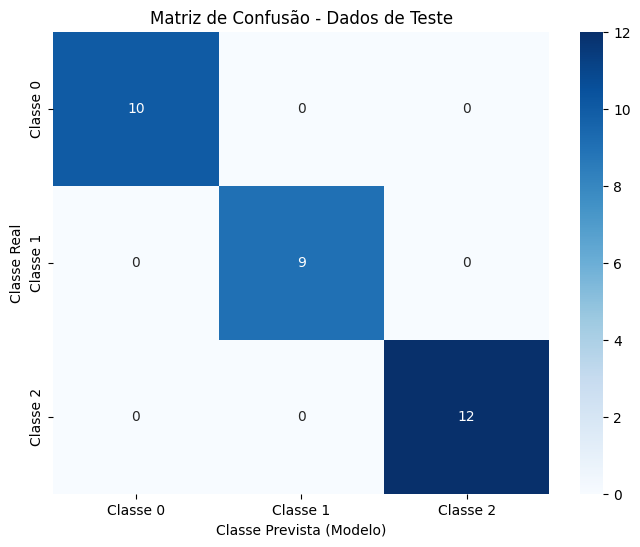

In [16]:
# loading the scaled data and encoded labels for training the MLP model
X_train_scaled = np.loadtxt('..\\data\\X_train_scaled.csv', delimiter=',')
y_train_encoded = np.loadtxt('..\\data\\y_train_encoded.csv', delimiter=',')

# loading the test data for later evaluation of the MLP model
X_test_scaled = np.loadtxt('..\\data\\X_test_scaled.csv', delimiter=',')   
y_test_encoded = np.loadtxt('..\\data\\y_test_encoded.csv', delimiter=',')

# undoing the one-hot encoding to calculate the test loss and accuracy after training the MLP models
y_test_true_labels_single = np.argmax(y_test_encoded, axis=1)

# Example of training the MLP with user-defined architecture and hyperparameters
final_loss_single, trained_model_single = single_train(X_train_scaled, y_train_encoded, epochs=150)

# seeing the test loss for the model trained with user-defined hyperparameters
y_test_pred_single = trained_model_single.forward_pass(X_test_scaled)

# undooing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_single = np.argmax(y_test_pred_single, axis=1)

# calculating the metrics for the model trained with user-defined hyperparameters

# calculating the test loss using cross-entropy loss formula
test_loss_single = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_single + 1e-8), axis=1))
print(f"Test Loss for the model trained with user-defined hyperparameters: {test_loss_single:.4f}")

# calculating the test accuracy by comparing the true labels with the predicted labels for the test set
test_accuracy_single = accuracy_score(y_test_true_labels_single, y_test_pred_labels_single)
print(f"Test Accuracy for the model trained with user-defined hyperparameters: {test_accuracy_single:.4f}")

# calculating teh precision
test_precision_single = precision_score(y_test_true_labels_single, y_test_pred_labels_single, average='weighted')
print(f"Test Precision for the model trained with user-defined hyperparameters: {test_precision_single:.4f}")

# calculating the recall
test_recall_single = recall_score(y_test_true_labels_single, y_test_pred_labels_single, average='weighted')
print(f"Test Recall for the model trained with user-defined hyperparameters: {test_recall_single:.4f}")

# calculating the F1-score
test_f1_single = f1_score(y_test_true_labels_single, y_test_pred_labels_single, average='weighted')
print(f"Test F1-Score for the model trained with user-defined hyperparameters: {test_f1_single:.4f}")

# calculating the classification report (precision, recall, F1-score) for each class using the true labels and predicted labels for the test set
classification_rep_single = classification_report(y_test_true_labels_single, y_test_pred_labels_single)
print(f"Classification Report for the model trained with user-defined hyperparameters:\n{classification_rep_single}")

# plotting the confusion matrix for the model trained with user-defined hyperparameters to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels_single, y_test_pred_labels_single)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()

## training with the random method

Training with random configuration 1/1000
Epoch 1/150
Epoch Loss: 1.1161
Epoch 11/150
Epoch Loss: 1.1148
Epoch 21/150
Epoch Loss: 1.1147
Epoch 31/150
Epoch Loss: 1.1129
Epoch 41/150
Epoch Loss: 1.1112
Epoch 51/150
Epoch Loss: 1.1084
Epoch 61/150
Epoch Loss: 1.1040
Epoch 71/150
Epoch Loss: 1.0983
Epoch 81/150
Epoch Loss: 1.0883
Epoch 91/150
Epoch Loss: 1.0740
Epoch 101/150
Epoch Loss: 1.0498
Epoch 111/150
Epoch Loss: 1.0117
Epoch 121/150
Epoch Loss: 0.9505
Epoch 131/150
Epoch Loss: 0.8584
Epoch 141/150
Epoch Loss: 0.7370
Epoch 150/150
Epoch Loss: 0.6195
Final Loss for this configuration: 0.6071
Training with random configuration 2/1000
Epoch 1/150
Epoch Loss: 1.1145
Epoch 11/150
Epoch Loss: 1.1144
Epoch 21/150
Epoch Loss: 1.1142
Epoch 31/150
Epoch Loss: 1.1141
Epoch 41/150
Epoch Loss: 1.1139
Epoch 51/150
Epoch Loss: 1.1138
Epoch 61/150
Epoch Loss: 1.1136
Epoch 71/150
Epoch Loss: 1.1135
Epoch 81/150
Epoch Loss: 1.1134
Epoch 91/150
Epoch Loss: 1.1132
Epoch 101/150
Epoch Loss: 1.1131
Epoch

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:83: RuntimeWarning: overflow encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:63: RuntimeWarning: invalid value encountered in subtract
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))


Epoch 11/150
Epoch Loss: 1.1245
Epoch 21/150
Epoch Loss: 1.1174
Epoch 31/150
Epoch Loss: 1.1169
Epoch 41/150
Epoch Loss: 1.1181
Epoch 51/150
Epoch Loss: 1.1177
Epoch 61/150
Epoch Loss: 1.1168
Epoch 71/150
Epoch Loss: 1.1165
Epoch 81/150
Epoch Loss: 1.1166
Epoch 91/150
Epoch Loss: 1.1166
Epoch 101/150
Epoch Loss: 1.1165
Epoch 111/150
Epoch Loss: 1.1165
Epoch 121/150
Epoch Loss: 1.1165
Epoch 131/150
Epoch Loss: 1.1165
Epoch 141/150
Epoch Loss: 1.1165
Epoch 150/150
Epoch Loss: 1.1165
Final Loss for this configuration: 1.1165
Training with random configuration 14/1000
Epoch 1/150
Epoch Loss: 1.1301
Epoch 11/150
Epoch Loss: 1.1183
Epoch 21/150
Epoch Loss: 1.1197
Epoch 31/150
Epoch Loss: 1.1152
Epoch 41/150
Epoch Loss: 1.1123
Epoch 51/150
Epoch Loss: 1.1097
Epoch 61/150
Epoch Loss: 1.1059
Epoch 71/150
Epoch Loss: 1.1027
Epoch 81/150
Epoch Loss: 1.0982
Epoch 91/150
Epoch Loss: 1.0932
Epoch 101/150
Epoch Loss: 1.0869
Epoch 111/150
Epoch Loss: 1.0789
Epoch 121/150
Epoch Loss: 1.0686
Epoch 131/1

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:83: RuntimeWarning: invalid value encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]


Epoch 101/150
Epoch Loss: 1.1083
Epoch 111/150
Epoch Loss: 1.1080
Epoch 121/150
Epoch Loss: 1.1077
Epoch 131/150
Epoch Loss: 1.1074
Epoch 141/150
Epoch Loss: 1.1071
Epoch 150/150
Epoch Loss: 1.1068
Final Loss for this configuration: 1.1068
Training with random configuration 53/1000
Epoch 1/150
Epoch Loss: 1.1180
Epoch 11/150
Epoch Loss: 1.1095
Epoch 21/150
Epoch Loss: 1.0992
Epoch 31/150
Epoch Loss: 1.0680
Epoch 41/150
Epoch Loss: 0.9452
Epoch 51/150
Epoch Loss: 0.7047
Epoch 61/150
Epoch Loss: 0.5039
Epoch 71/150
Epoch Loss: 0.3513
Epoch 81/150
Epoch Loss: 0.2733
Epoch 91/150
Epoch Loss: 3.3626
Epoch 101/150
Epoch Loss: 0.8481
Epoch 111/150
Epoch Loss: 9.2198
Epoch 121/150
Epoch Loss: 1.5127
Epoch 131/150
Epoch Loss: 1.2697
Epoch 141/150
Epoch Loss: 1.1547
Epoch 150/150
Epoch Loss: 1.1246
Final Loss for this configuration: 1.1233
Training with random configuration 54/1000
Epoch 1/150
Epoch Loss: 1.1243
Epoch 11/150
Epoch Loss: 1.1203
Epoch 21/150
Epoch Loss: 1.1134
Epoch 31/150
Epoch L

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:137: RuntimeWarning: overflow encountered in dot
  propagation_error = np.dot(error, self.weights[i].T)
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:148: RuntimeWarning: invalid value encountered in multiply
  error = propagation_error * activation_derivative


Epoch Loss: 1.1049
Epoch 91/150
Epoch Loss: 1.1027
Epoch 101/150
Epoch Loss: 1.1001
Epoch 111/150
Epoch Loss: 1.0971
Epoch 121/150
Epoch Loss: 1.0935
Epoch 131/150
Epoch Loss: 1.0892
Epoch 141/150
Epoch Loss: 1.0840
Epoch 150/150
Epoch Loss: 1.0784
Final Loss for this configuration: 1.0777
Training with random configuration 88/1000
Epoch 1/150
Epoch Loss: 1.1309
Epoch 11/150
Epoch Loss: 1.1297
Epoch 21/150
Epoch Loss: 1.1284
Epoch 31/150
Epoch Loss: 1.1272
Epoch 41/150
Epoch Loss: 1.1261
Epoch 51/150
Epoch Loss: 1.1251
Epoch 61/150
Epoch Loss: 1.1243
Epoch 71/150
Epoch Loss: 1.1236
Epoch 81/150
Epoch Loss: 1.1229
Epoch 91/150
Epoch Loss: 1.1223
Epoch 101/150
Epoch Loss: 1.1218
Epoch 111/150
Epoch Loss: 1.1213
Epoch 121/150
Epoch Loss: 1.1209
Epoch 131/150
Epoch Loss: 1.1206
Epoch 141/150
Epoch Loss: 1.1203
Epoch 150/150
Epoch Loss: 1.1200
Final Loss for this configuration: 1.1200
Training with random configuration 89/1000
Epoch 1/150
Epoch Loss: 1.1166
Epoch 11/150
Epoch Loss: 0.7511
E

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_20604\2484621655.py:63: RuntimeWarning: overflow encountered in subtract
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))


Epoch 51/150
Epoch Loss: 1.1168
Epoch 61/150
Epoch Loss: 1.1172
Epoch 71/150
Epoch Loss: 1.1172
Epoch 81/150
Epoch Loss: 1.1169
Epoch 91/150
Epoch Loss: 1.1167
Epoch 101/150
Epoch Loss: 1.1165
Epoch 111/150
Epoch Loss: 1.1165
Epoch 121/150
Epoch Loss: 1.1165
Epoch 131/150
Epoch Loss: 1.1165
Epoch 141/150
Epoch Loss: 1.1165
Epoch 150/150
Epoch Loss: 1.1165
Final Loss for this configuration: 1.1165
Training with random configuration 353/1000
Epoch 1/150
Epoch Loss: 1.2097
Epoch 11/150
Epoch Loss: 1.2077
Epoch 21/150
Epoch Loss: 1.2048
Epoch 31/150
Epoch Loss: 1.2019
Epoch 41/150
Epoch Loss: 1.1991
Epoch 51/150
Epoch Loss: 1.1964
Epoch 61/150
Epoch Loss: 1.1938
Epoch 71/150
Epoch Loss: 1.1913
Epoch 81/150
Epoch Loss: 1.1888
Epoch 91/150
Epoch Loss: 1.1865
Epoch 101/150
Epoch Loss: 1.1842
Epoch 111/150
Epoch Loss: 1.1820
Epoch 121/150
Epoch Loss: 1.1799
Epoch 131/150
Epoch Loss: 1.1778
Epoch 141/150
Epoch Loss: 1.1758
Epoch 150/150
Epoch Loss: 1.1741
Final Loss for this configuration: 1.17

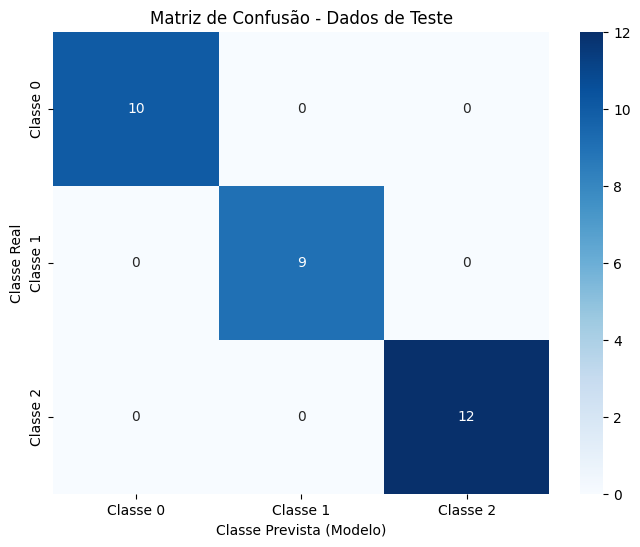

In [14]:
# loading the scaled data and encoded labels for training the MLP model
X_train_scaled = np.loadtxt('..\\data\\X_train_scaled.csv', delimiter=',')
y_train_encoded = np.loadtxt('..\\data\\y_train_encoded.csv', delimiter=',')

# loading the test data for later evaluation of the best MLP model found
X_test_scaled = np.loadtxt('..\\data\\X_test_scaled.csv', delimiter=',')   
y_test_encoded = np.loadtxt('..\\data\\y_test_encoded.csv', delimiter=',')

# undoing the one-hot encoding to calculate the test loss and accuracy after training the MLP models
y_test_true_labels_random = np.argmax(y_test_encoded, axis=1)

# Executing the random search method to train multiple configurations and find the best MLP architecture and hyperparameters
trained_model_random, parameters, all_results = random_train(X_train_scaled, y_train_encoded, epochs=150)

# getting the predictions to calculate the test loss for the best model found by the random search method
y_test_pred_random = trained_model_random.forward_pass(X_test_scaled)

# undoing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_random = np.argmax(y_test_pred_random, axis=1)

# calculating the evaluation metrics for the best model found by the random search method

# calculating the test loss using cross-entropy loss formula
test_loss_random = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_random + 1e-8), axis=1))
print(f"Test Loss for the best model found by random search: {test_loss_random:.4f}")

# calculating the test accuracy
test_accuracy_random = accuracy_score(y_test_true_labels_random, y_test_pred_labels_random)
print(f"Test Accuracy for the best model found by random search: {test_accuracy_random:.4f}")

# calculating teh precision
test_precision_random = precision_score(y_test_true_labels_random, y_test_pred_labels_random, average='weighted')
print(f"Test Precision for the best model found by random search: {test_precision_random:.4f}")

# calculating the recall
test_recall_random = recall_score(y_test_true_labels_random, y_test_pred_labels_random, average='weighted')
print(f"Test Recall for the best model found by random search: {test_recall_random:.4f}")

# calculating the F1-score
test_f1_random = f1_score(y_test_true_labels_random, y_test_pred_labels_random, average='weighted')
print(f"Test F1-Score for the best model found by random search: {test_f1_random:.4f}")

# calculating the classification report (precision, recall, F1-score) for each class using the true labels and predicted labels for the test set
classification_rep_random = classification_report(y_test_true_labels_random, y_test_pred_labels_random)
print(f"Classification Report for the best model found by random search:\n{classification_rep_random}")

# plotting the confusion matrix for the best model found by the random search method to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels_random, y_test_pred_labels_random)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()